# Embodyment aware collaborated learning

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys

module_path = os.path.abspath(os.path.join("./src"))  # or the path to your source code
sys.path.insert(0, module_path)

# Setting up the learning environment

For training the agents, the
[gymnasium](https://github.com/Farama-Foundation/Gymnasium) packagage is
utilized. The gymnasium package is a collection of environments that can be
easily set up and used for training agents. 

In [12]:
import gymnasium
import hydra
import torch
from federated_learner import exp_manager, learning, visualization
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)

In [3]:
# The following device is used for training the agents:
print(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

mps


# Train on simple DeepQAgent


## Acrobot
Initialize the environment without rendering and fetch the dimensiont of the state and action
space.

The used environment is the Acrobot as described in [Sutton and Barto’s book Reinforcement Learning: An Introduction](http://incompleteideas.net/book/11/node4.html).

![Acrobot](./images/acrobot.gif)

This environment is part of the Classic Control environments which contains general information about the environment.

|  |  |
| --- | --- |
| Action Space | `Discrete(3)` |
| Observation Space | `Box([ -1. -1. -1. -1. -12.566371 -28.274334], [ 1. 1. 1. 1. 12.566371 28.274334], (6,), float32)` |
| import | `gymnasium.make("Acrobot-v1")` |

## Description

The Acrobot environment is based on Sutton’s work in [“Generalization in Reinforcement Learning: Successful Examples Using Sparse Coarse Coding”](https://papers.nips.cc/paper/1995/hash/8f1d43620bc6bb580df6e80b0dc05c48-Abstract.html) and [Sutton and Barto’s book](http://www.incompleteideas.net/book/the-book-2nd.html). The system consists of two links connected linearly to form a chain, with one end of the chain fixed. The joint between the two links is actuated. The goal is to apply torques on the actuated joint to swing the free end of the linear chain above a given height while starting from the initial state of hanging downwards.

As seen in the **Gif**: two blue links connected by two green joints. The joint in between the two links is actuated. The goal is to swing the free end of the outer-link to reach the target height (black horizontal line above system) by applying torque on the actuator.

### Action Space

The action is discrete, deterministic, and represents the torque applied on the actuated joint between the two links.

| Num | Action | Unit |
| --- | --- | --- |
| 0 | apply -1 torque to the actuated joint | torque (N m) |
| 1 | apply 0 torque to the actuated joint | torque (N m) |
| 2 | apply 1 torque to the actuated joint | torque (N m) |

### Observation Space

The observation is a `ndarray` with shape `(6,)` that provides information about the two rotational joint angles as well as their angular velocities:

| Num | Observation | Min | Max |
| --- | --- | --- | --- |
| 0 | Cosine of `theta1` | \-1 | 1 |
| 1 | Sine of `theta1` | \-1 | 1 |
| 2 | Cosine of `theta2` | \-1 | 1 |
| 3 | Sine of `theta2` | \-1 | 1 |
| 4 | Angular velocity of `theta1` | ~ -12.567 (-4 \* pi) | ~ 12.567 (4 \* pi) |
| 5 | Angular velocity of `theta2` | ~ -28.274 (-9 \* pi) | ~ 28.274 (9 \* pi) |

where

- `theta1` is the angle of the first joint, where an angle of 0 indicates the first link is pointing directly downwards.
- `theta2` is ***relative to the angle of the first link.*** An angle of 0 corresponds to having the same angle between the two links.

The angular velocities of `theta1` and `theta2` are bounded at ±4π, and ±9π rad/s respectively. A state of `[1, 0, 1, 0, ..., ...]` indicates that both links are pointing downwards.

### Rewards

The goal is to have the free end reach a designated target height in as few steps as possible, and as such all steps that do not reach the goal incur a reward of -1. Achieving the target height results in termination with a reward of 0. The reward threshold is -100.

### Starting State

Each parameter in the underlying state (`theta1`, `theta2`, and the two angular velocities) is initialized uniformly between -0.1 and 0.1. This means both links are pointing downwards with some initial stochasticity.

### Episode End

The episode ends if one of the following occurs:

1. Termination: The free end reaches the target height, which is constructed as: `-cos(theta1) - cos(theta2 + theta1) > 1.0`
2. Truncation: Episode length is greater than 500 (200 for v0)

### Arguments

Acrobot only has `render_mode` as a keyword for `gymnasium.make`. On reset, the `options` parameter allows the user to change the bounds used to determine the new random state.

```python
>>> import gymnasium as gym
>>> env = gym.make('Acrobot-v1', render_mode="rgb_array")
>>> env
<TimeLimit<OrderEnforcing<PassiveEnvChecker<AcrobotEnv<Acrobot-v1>>>>>
>>> env.reset(seed=123, options={"low": -0.2, "high": 0.2})  # default low=-0.1, high=0.1
(array([ 0.997341  ,  0.07287608,  0.9841162 , -0.17752565, -0.11185605,
       -0.12625128], dtype=float32), {})
```

By default, the dynamics of the acrobot follow those described in Sutton and Barto’s book [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/11/node4.html). However, a `book_or_nips` parameter can be modified to change the pendulum dynamics to those described in the original [NeurIPS paper](https://papers.nips.cc/paper/1995/hash/8f1d43620bc6bb580df6e80b0dc05c48-Abstract.html).

```python
# To change the dynamics as described above
env.unwrapped.book_or_nips = 'nips'
```

See the following note for details:

> The dynamics equations were missing some terms in the NIPS paper which are present in the book. R. Sutton confirmed in personal correspondence that the experimental results shown in the paper and the book were generated with the equations shown in the book. However, there is the option to run the domain with the paper equations by setting `book_or_nips = 'nips'`

### Version History

- v1: Maximum number of steps increased from 200 to 500. The observation space for v0 provided direct readings of `theta1` and `theta2` in radians, having a range of `[-pi, pi]`. The v1 observation space as described here provides the sine and cosine of each angle instead.
- v0: Initial versions release

### References

- Sutton, R. S. (1996). Generalization in Reinforcement Learning: Successful Examples Using Sparse Coarse Coding. In D. Touretzky, M. C. Mozer, & M. Hasselmo (Eds.), Advances in Neural Information Processing Systems (Vol. 8). MIT Press. https://proceedings.neurips.cc/paper/1995/file/8f1d43620bc6bb580df6e80b0dc05c48-Paper.pdf
- Sutton, R. S., Barto, A. G. (2018 ). Reinforcement Learning: An Introduction. The MIT Press.

In [4]:
env = gymnasium.make("Acrobot-v1")
state, info = env.reset()
state_dim = len(state)
action_dim = env.action_space.n
print(f"State dimension: {state_dim} and Action dimension: {action_dim}")

State dimension: 6 and Action dimension: 3


In [5]:
# Print full configuration
hydra.initialize(version_base=None, config_path="config")

hydra.initialize()

In [6]:
cfg = hydra.compose("default")
print(cfg)

{'experiment': {'seed': 42, 'fill_buffer': True, 'num_episodes': 1000, 'test_interval': 25, 'test_episodes': 100}, 'agent': {'agent_type': 'DQNAgent', 'model': 'DeepQNetwork', 'learning_rate': 0.0001, 'tau': 0.05, 'gamma': 0.99, 'epsilon_start': 0.99, 'epsilon_decay': 1000, 'epsilon_end': 0.05, 'buffer_size': 10000, 'batch_size': 128}, 'environment': {'env_id': 'Acrobot-v1'}}


The utilized optimizer is the
[AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW) optimizer.

It uses a simple neural network with two hidden layers of 8 units each.

![VAE](./images/VAE_Basic.png)

In [7]:
env = exp_manager.make_env(cfg)
agent = exp_manager.make_agent(cfg, env)
learn= learning.LearningSuite(cfg, agent, env)

In [8]:
average_reward_list, std_reward_list, episode_durations = learn.train_over_episodes()

  0%|          | 0/1000 [00:00<?, ?it/s]

Episode 0 --> Average Total Reward (Evaluation): -500.0 (±0.0)


  2%|▎         | 25/1000 [01:16<17:30,  1.08s/it]  

Episode 25 --> Average Total Reward (Evaluation): -85.75 (±15.696735329360688)


  5%|▌         | 50/1000 [01:46<14:08,  1.12it/s]

...

Episode 950 --> Average Total Reward (Evaluation): -84.5 (±19.500512813769795)


 98%|█████████▊| 975/1000 [1:07:38<01:39,  3.99s/it]

Episode 975 --> Average Total Reward (Evaluation): -85.91 (±43.95135834078396)


100%|██████████| 1000/1000 [1:09:26<00:00,  4.17s/it]


Episode 999 --> Average Total Reward (Evaluation): -96.21 (±24.55740010668882)


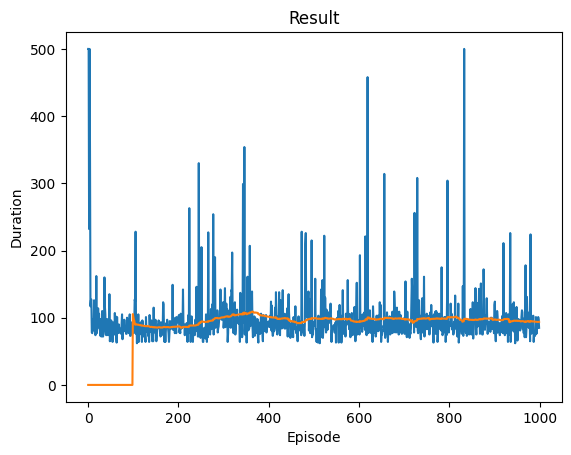

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [13]:
visualization.plot_durations(episode_durations, show_result=True)
plt.show()

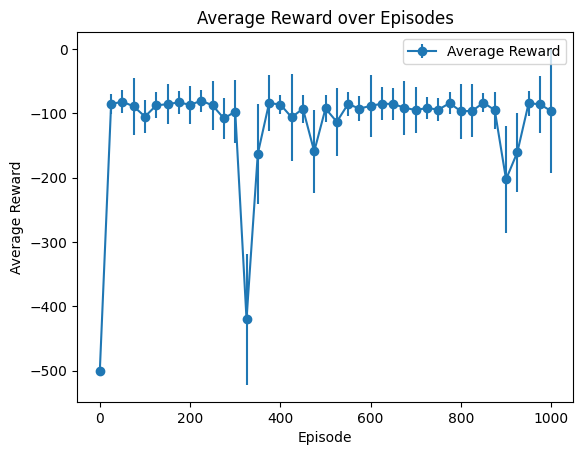

In [14]:
Övisualization.plot_reward(average_reward_list, std_reward_list)